In [1]:
%reload_ext autoreload
%autoreload 3
import os
from pathlib import Path
import sys
sys.path.append(str(Path(os.getcwd()).parent / 'src'))
from forecastpnn.utils.data_functions import get_dataset
import torch
torch.use_deterministic_algorithms(True) # reproducibility
import pandas as pd

from forecastpnn.utils.train_utils import SubsetSampler as SS
from forecastpnn.utils.constants import RANDOM_SEED

data = pd.read_csv('../data/derived/DENGSP.csv')
dl = get_dataset(data, 'DT_SIN_PRI', weeks_in=False, weeks_out=False, past_units=30, return_df=True, filter_year_min=2013, filter_year_max=2020, dow=False)


/var/folders/xr/mqd4g8995xqfhcvcyvr2smdc0000gn/T/ipykernel_1412/3552699038.py:15: DtypeWarning: Columns (7,11,23,45,46,47,55,65,69,75,86,102) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/derived/DENGSP.csv')


In [3]:
bounds = [pd.date_range("2013-01-01", "2013-07-01"), pd.date_range("2014-02-01", "2014-07-01"), pd.date_range("2015-01-01", "2015-07-01"), pd.date_range("2015-11-01", "2016-07-01"), pd.date_range("2016-09-01", "2017-07-01"), pd.date_range("2017-08-01", "2018-08-01"), pd.date_range("2019-01-01", "2019-08-01"), pd.date_range("2019-12-15", "2020-07-01")]

from scipy.stats import skewnorm
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import skewnorm
def print_true_outbreak_vs_fitted_values_subs(samples, alpha, mu, sigma, samples_subs = None, density=True, size_based_on_cdf = True):
    num_samples = len(samples)
    # Find size to sample from estimated from subsample
    if samples_subs is not None:
        if size_based_on_cdf:
            prob_until_cutoff = skewnorm.cdf(samples_subs.max(), alpha, mu, sigma)
            num_samples_opt = int(min(len(samples_subs)/prob_until_cutoff, 10_000_000))
        else:
            prob_at_cutoff = skewnorm.pdf(samples_subs.max(), alpha, mu, sigma)
            num_samples_opt = int(min(len(samples_subs[samples_subs == samples_subs.max()])/prob_at_cutoff, 10_000_000))
        samples_opt = skewnorm.rvs(alpha, mu, sigma, size=num_samples_opt, random_state=42)
    else:
        samples_opt = skewnorm.rvs(alpha, mu, sigma, size=num_samples, random_state=42)

    # Create integer bins that cover both datasets
    min_val = int(min(min(samples), min(samples_opt)))
    max_val = int(np.ceil(max(max(samples), max(samples_opt))))
    bins = np.arange(min_val, max_val + 1)

    plt.figure(figsize=(5, 3))
    plt.hist(samples, bins=bins, label='Original Samples', density=density, color = "black")
    if samples_subs is not None:
        plt.hist(samples_subs, bins=bins, label='Original Samples Subs', density=density, color = "dodgerblue")
    plt.hist(samples_opt, bins=bins, alpha=0.8, label='Fitted Samples', density=density, color = "crimson")
    plt.legend(loc='upper right')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title('Original vs Fitted Skew Normal Distribution')
    plt.show()

------------------------ Outbreak 1 -----------------------


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:08<00:00, 113.14it/s]


Optimized parameters: mu=54.85, sigma=51.69, alpha=1.58, estimate of the mode: 83.01


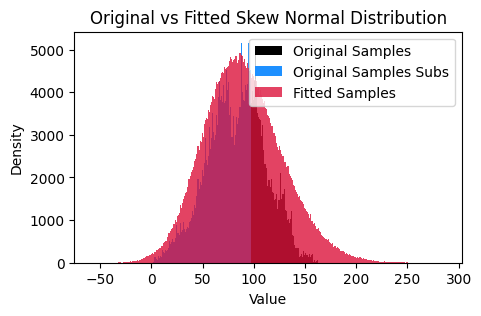

100%|██████████| 1000/1000 [00:08<00:00, 120.58it/s]


Optimized parameters: mu=46.54, sigma=48.41, alpha=1.60, estimate of the mode: 72.87


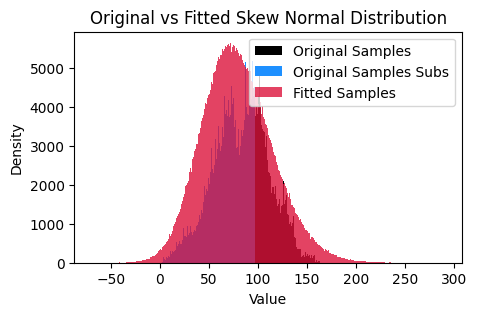

100%|██████████| 1000/1000 [00:09<00:00, 109.77it/s]


Optimized parameters: mu=45.50, sigma=47.82, alpha=1.60, estimate of the mode: 71.48


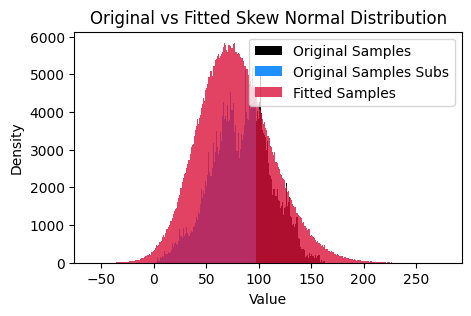

100%|██████████| 1000/1000 [00:08<00:00, 115.65it/s]


Optimized parameters: mu=45.98, sigma=48.12, alpha=1.60, estimate of the mode: 72.17


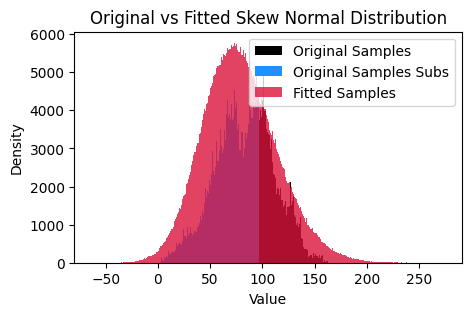

100%|██████████| 1000/1000 [00:08<00:00, 116.64it/s]


Optimized parameters: mu=50.29, sigma=50.04, alpha=1.58, estimate of the mode: 77.53


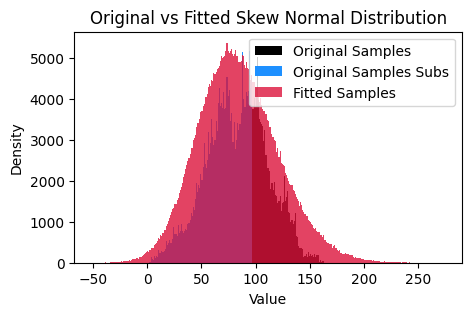

------------------------ Outbreak 2 -----------------------


100%|██████████| 1000/1000 [00:08<00:00, 124.46it/s]


Optimized parameters: mu=44.45, sigma=46.82, alpha=1.60, estimate of the mode: 69.95


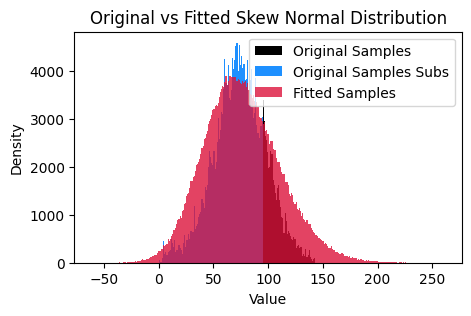

100%|██████████| 1000/1000 [00:08<00:00, 112.74it/s]


Optimized parameters: mu=52.10, sigma=50.05, alpha=1.57, estimate of the mode: 79.32


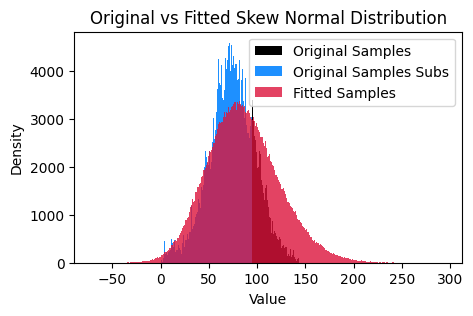

100%|██████████| 1000/1000 [00:08<00:00, 113.22it/s]


Optimized parameters: mu=48.47, sigma=48.47, alpha=1.59, estimate of the mode: 74.87


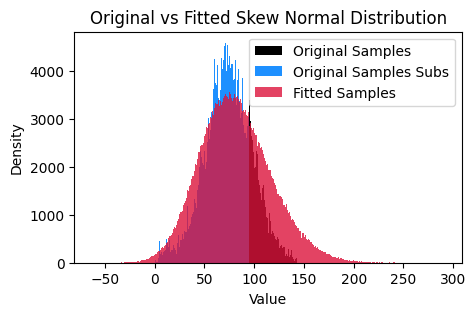

100%|██████████| 1000/1000 [00:09<00:00, 109.58it/s]


Optimized parameters: mu=56.75, sigma=52.07, alpha=1.57, estimate of the mode: 85.10


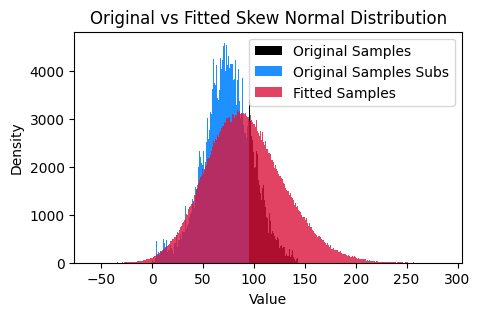

100%|██████████| 1000/1000 [00:08<00:00, 119.69it/s]


Optimized parameters: mu=48.09, sigma=48.48, alpha=1.59, estimate of the mode: 74.50


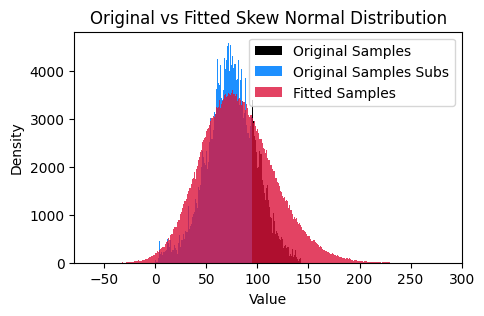

------------------------ Outbreak 3 -----------------------


100%|██████████| 1000/1000 [00:21<00:00, 46.84it/s]


Optimized parameters: mu=47.37, sigma=50.65, alpha=1.59, estimate of the mode: 74.97


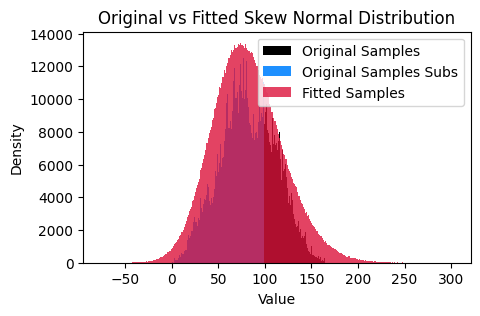

100%|██████████| 1000/1000 [00:21<00:00, 46.76it/s]


Optimized parameters: mu=57.76, sigma=54.83, alpha=1.57, estimate of the mode: 87.59


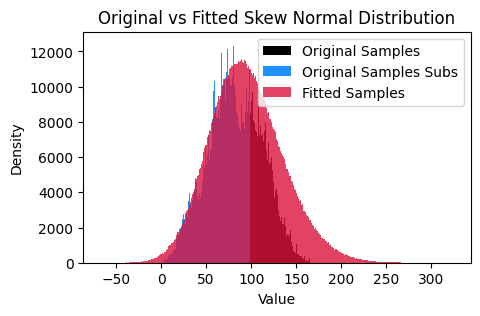

100%|██████████| 1000/1000 [00:23<00:00, 43.26it/s]


Optimized parameters: mu=50.47, sigma=51.55, alpha=1.57, estimate of the mode: 78.49


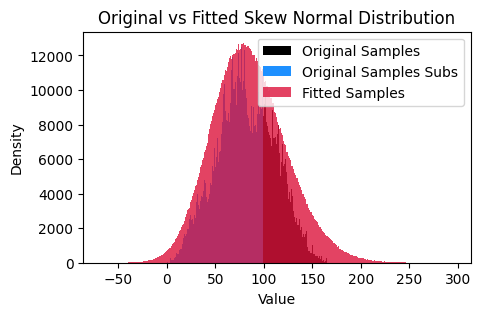

100%|██████████| 1000/1000 [00:21<00:00, 45.79it/s]


Optimized parameters: mu=39.93, sigma=46.08, alpha=1.62, estimate of the mode: 64.98


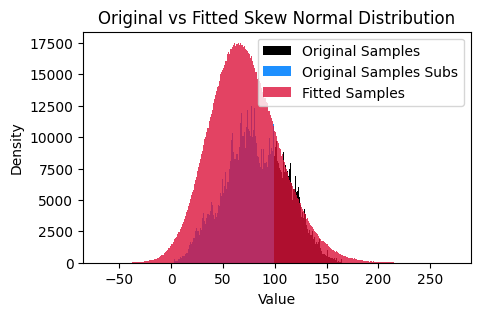

100%|██████████| 1000/1000 [00:20<00:00, 48.95it/s]


Optimized parameters: mu=43.55, sigma=48.41, alpha=1.61, estimate of the mode: 69.89


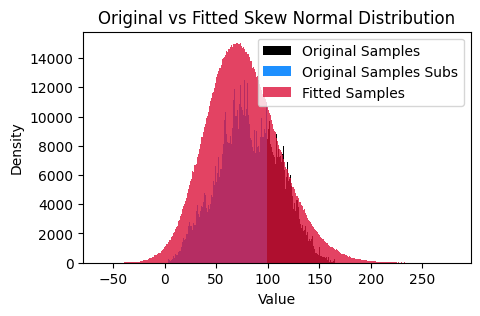

------------------------ Outbreak 4 -----------------------


100%|██████████| 1000/1000 [00:05<00:00, 184.48it/s]


Optimized parameters: mu=88.38, sigma=60.92, alpha=1.54, estimate of the mode: 121.52


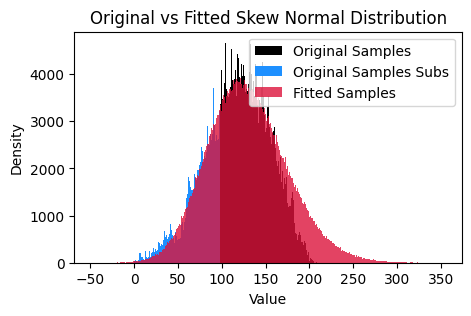

100%|██████████| 1000/1000 [00:05<00:00, 182.64it/s]


Optimized parameters: mu=98.58, sigma=63.83, alpha=1.54, estimate of the mode: 133.33


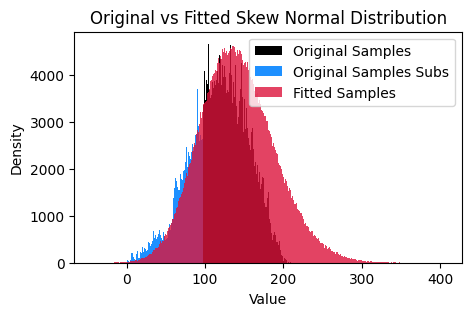

100%|██████████| 1000/1000 [00:05<00:00, 178.14it/s]


Optimized parameters: mu=92.47, sigma=62.11, alpha=1.54, estimate of the mode: 126.28


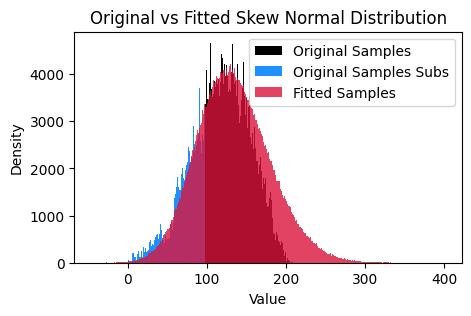

100%|██████████| 1000/1000 [00:05<00:00, 180.87it/s]


Optimized parameters: mu=84.48, sigma=59.75, alpha=1.54, estimate of the mode: 117.05


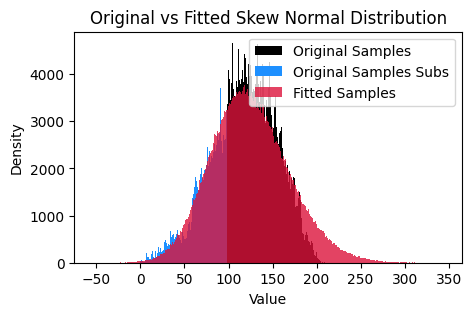

100%|██████████| 1000/1000 [00:05<00:00, 188.60it/s]


Optimized parameters: mu=89.78, sigma=61.33, alpha=1.54, estimate of the mode: 123.16


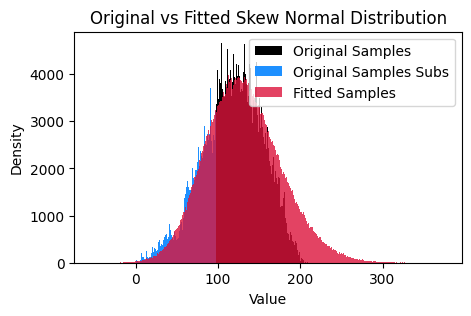

------------------------ Outbreak 5 -----------------------


100%|██████████| 1000/1000 [00:02<00:00, 434.13it/s]


Optimized parameters: mu=115.81, sigma=75.97, alpha=1.54, estimate of the mode: 157.16


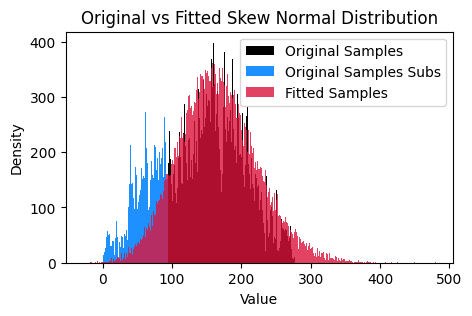

100%|██████████| 1000/1000 [00:02<00:00, 492.79it/s]


Optimized parameters: mu=113.17, sigma=75.19, alpha=1.53, estimate of the mode: 154.12


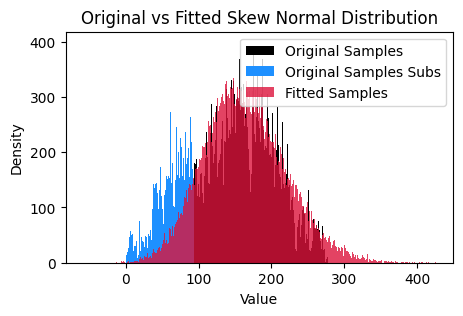

100%|██████████| 1000/1000 [00:02<00:00, 441.56it/s]


Optimized parameters: mu=121.36, sigma=77.60, alpha=1.54, estimate of the mode: 163.58


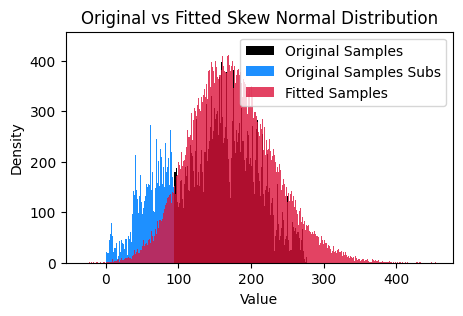

100%|██████████| 1000/1000 [00:02<00:00, 417.24it/s]


Optimized parameters: mu=119.84, sigma=77.16, alpha=1.55, estimate of the mode: 161.81


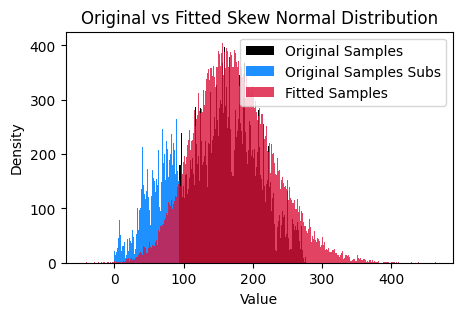

100%|██████████| 1000/1000 [00:02<00:00, 407.91it/s]


Optimized parameters: mu=121.93, sigma=77.77, alpha=1.52, estimate of the mode: 164.24


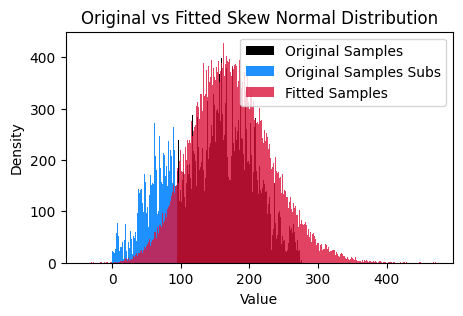

------------------------ Outbreak 6 -----------------------


100%|██████████| 1000/1000 [00:02<00:00, 392.44it/s]


Optimized parameters: mu=47.42, sigma=52.06, alpha=1.58, estimate of the mode: 75.78


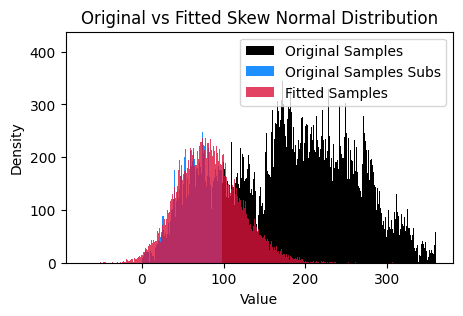

100%|██████████| 1000/1000 [00:03<00:00, 250.33it/s]


Optimized parameters: mu=48.60, sigma=52.66, alpha=1.57, estimate of the mode: 77.25


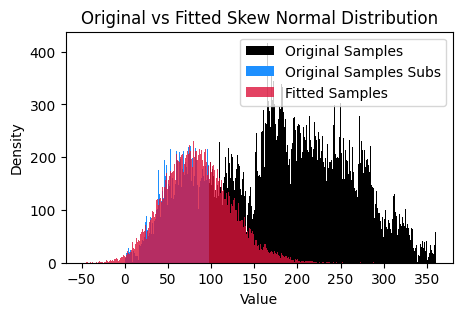

100%|██████████| 1000/1000 [00:02<00:00, 437.54it/s]


Optimized parameters: mu=44.16, sigma=50.93, alpha=1.58, estimate of the mode: 71.85


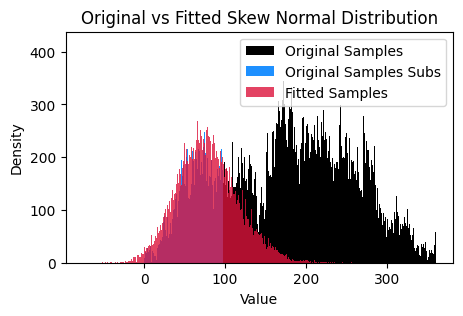

100%|██████████| 1000/1000 [00:04<00:00, 205.10it/s]


Optimized parameters: mu=47.30, sigma=52.00, alpha=1.58, estimate of the mode: 75.58


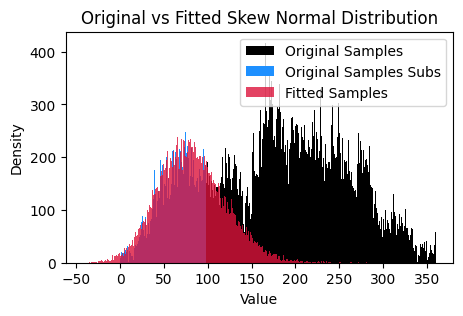

100%|██████████| 1000/1000 [00:02<00:00, 412.26it/s]


Optimized parameters: mu=42.97, sigma=50.19, alpha=1.59, estimate of the mode: 70.27


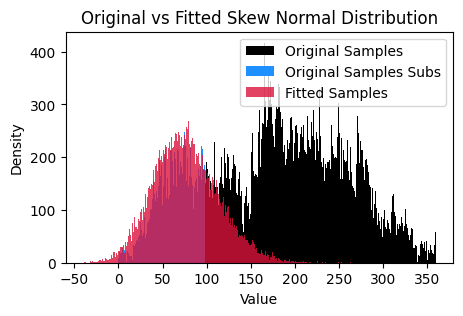

------------------------ Outbreak 7 -----------------------


100%|██████████| 1000/1000 [08:31<00:00,  1.96it/s] 


Optimized parameters: mu=84.95, sigma=65.16, alpha=1.55, estimate of the mode: 120.41


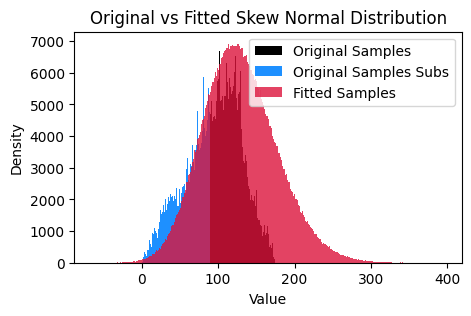

100%|██████████| 1000/1000 [00:09<00:00, 105.37it/s]


Optimized parameters: mu=89.08, sigma=66.55, alpha=1.54, estimate of the mode: 125.30


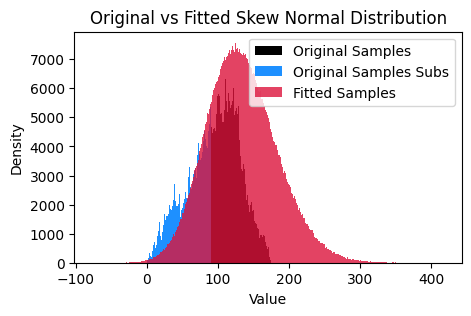

100%|██████████| 1000/1000 [00:08<00:00, 117.34it/s]


Optimized parameters: mu=96.21, sigma=68.88, alpha=1.54, estimate of the mode: 133.71


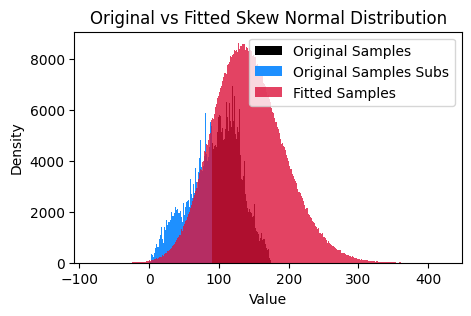

100%|██████████| 1000/1000 [00:08<00:00, 120.59it/s]


Optimized parameters: mu=87.99, sigma=66.19, alpha=1.55, estimate of the mode: 124.00


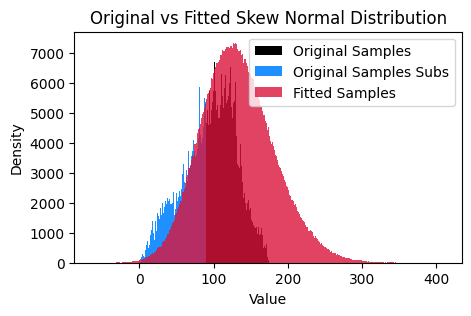

100%|██████████| 1000/1000 [00:08<00:00, 118.30it/s]


Optimized parameters: mu=87.19, sigma=65.93, alpha=1.54, estimate of the mode: 123.03


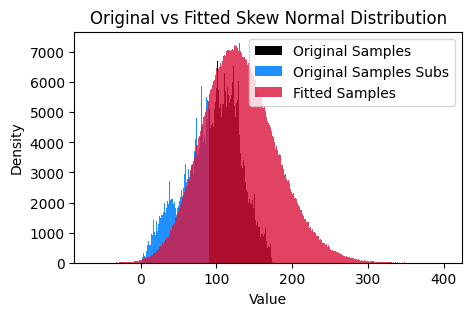

------------------------ Outbreak 8 -----------------------


100%|██████████| 1000/1000 [00:07<00:00, 140.65it/s]


Optimized parameters: mu=34.57, sigma=45.13, alpha=1.58, estimate of the mode: 59.16


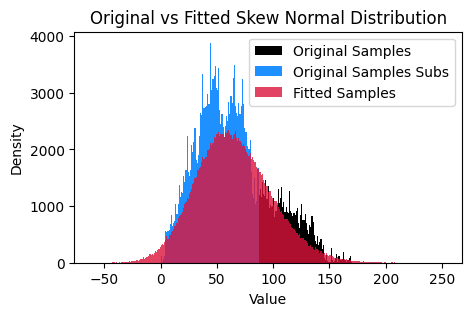

100%|██████████| 1000/1000 [00:07<00:00, 137.55it/s]


Optimized parameters: mu=26.58, sigma=38.11, alpha=1.63, estimate of the mode: 47.34


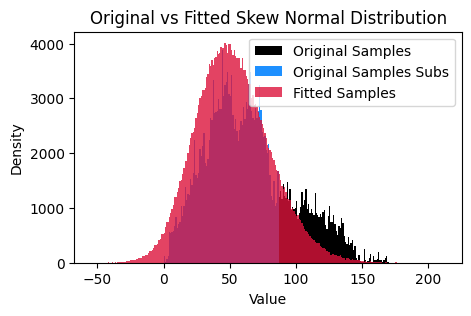

100%|██████████| 1000/1000 [00:06<00:00, 143.45it/s]


Optimized parameters: mu=35.21, sigma=45.31, alpha=1.58, estimate of the mode: 59.86


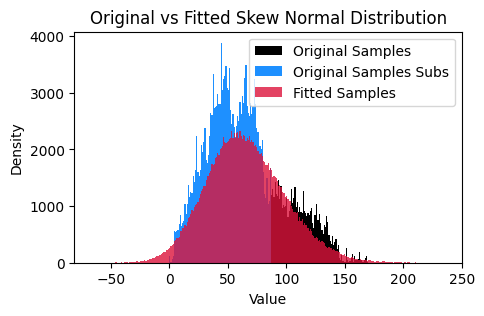

100%|██████████| 1000/1000 [00:06<00:00, 143.97it/s]


Optimized parameters: mu=34.61, sigma=45.16, alpha=1.58, estimate of the mode: 59.16


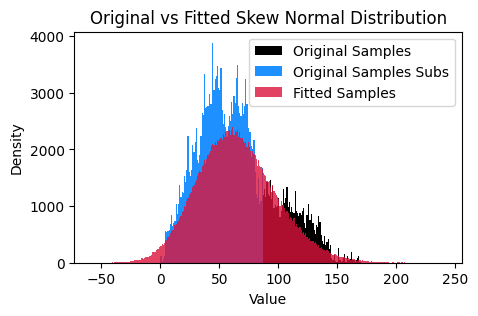

100%|██████████| 1000/1000 [00:07<00:00, 136.71it/s]


Optimized parameters: mu=31.06, sigma=42.41, alpha=1.61, estimate of the mode: 54.15


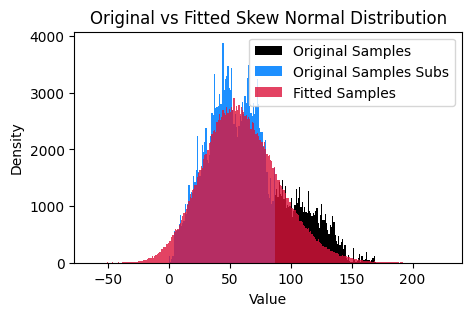

In [9]:
from forecastpnn.models.dist_optimizer import optimize_params

import scipy
from tqdm import tqdm
from scipy.stats import skewnorm

modes = [75, 80, 75, 120, 160, 75, 120, 60]
SAMPLES_SEEN = 100
BOOTSTRAP_ITERS = 5
DECAY = 0.99  # Future idea, problem with pdf to fit and correct calculation of total samples
for i, dr in enumerate(bounds):
    print(f"------------------------ Outbreak {i+1} -----------------------")
    #samples = daily_df.loc[dr, "count"]
    samples = dl.loc[dr, "count"].astype(int)  # Try out with smoothed data
    samples_subs = samples.iloc[:SAMPLES_SEEN].values
    samples_subs = samples_subs - samples.iloc[0]
    max_val = samples_subs.max()
    samples = samples.values - samples.iloc[0]
    samples_subs = samples_subs[samples_subs > 0]
    samples = samples[samples > 0]
    samples_array = np.repeat(np.arange(len(samples)), samples)
    samples_subs_array = np.repeat(np.arange(len(samples_subs)), samples_subs)
    for _ in range(BOOTSTRAP_ITERS):
        mode = modes[i] + np.random.normal(0, 5)
        alpha, mu, sigma = optimize_params(samples_subs_array, peak_loc=mode, lambda_loc=10*max_val, lambda_alpha=1e4)
        print(f"Optimized parameters: mu={mu:.2f}, sigma={sigma:.2f}, alpha={alpha:.2f}, estimate of the mode: {mode:.2f}")
        print_true_outbreak_vs_fitted_values_subs(samples_array, alpha, mu, sigma, samples_subs_array, density=False, size_based_on_cdf = False)